In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("All ML models imported successfully!")

All ML models imported successfully!


In [12]:
data = {
    "Study_Hours": [2, 3, 4, 5, 6, 1, 7, 8, 3, 5, 6, 2, 9, 4, 7],
    "Attendance": [60, 70, 75, 80, 85, 50, 90, 95, 65, 78, 88, 55, 98, 72, 92],
    "Previous_Marks": [45, 50, 55, 60, 65, 35, 75, 85, 48, 62, 70, 40, 90, 58, 80],
    "Final_Marks": [48, 52, 58, 65, 70, 38, 78, 88, 50, 64, 73, 42, 94, 60, 83]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print(df.head())
print("\nDataset shape:", df.shape)

Dataset created successfully!
   Study_Hours  Attendance  Previous_Marks  Final_Marks
0            2          60              45           48
1            3          70              50           52
2            4          75              55           58
3            5          80              60           65
4            6          85              65           70

Dataset shape: (15, 4)


In [14]:
X = df[["Study_Hours", "Attendance", "Previous_Marks"]]
y = df["Final_Marks"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Study_Hours  Attendance  Previous_Marks
0            2          60              45
1            3          70              50
2            4          75              55
3            5          80              60
4            6          85              65

Target (y):
0    48
1    52
2    58
3    65
4    70
Name: Final_Marks, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Data split successfully!")

Training samples: 12
Testing samples: 3
Data split successfully!


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

X_test_check = np.array([
    [2, 60, 45],
    [4, 75, 55],
    [6, 85, 65],
    [8, 95, 85]
])
y_test_check = np.array([48, 58, 70, 88])

model_check = LinearRegression()
model_check.fit(X_test_check, y_test_check)

print("Linear Regression fit successful!")

Linear Regression fit successful!


In [26]:
import narwhals._utils as u
print("Function exists:", hasattr(u, "str_slice_stop"))

Function exists: False


In [28]:
# Train Linear Regression using NumPy
X_array = X_train.to_numpy(dtype=float)
y_array = y_train.to_numpy(dtype=float)

# Add intercept column
X_with_intercept = np.column_stack([
    np.ones(len(X_array)),
    X_array
])

coefficients = np.linalg.lstsq(
    X_with_intercept, y_array, rcond=None
)[0]

print("Linear Regression training successful!")
print("Coefficients:", coefficients)

Linear Regression training successful!
Coefficients: [ 1.15949442e+01  2.48246662e+00 -3.89630671e-03  6.70824549e-01]


In [29]:
# Predict marks for test data
X_test_array = X_test.to_numpy(dtype=float)

X_test_with_intercept = np.column_stack([
    np.ones(len(X_test_array)),
    X_test_array
])

y_pred = X_test_with_intercept @ coefficients

results = pd.DataFrame({
    "Actual_Marks": y_test.to_numpy(),
    "Predicted_Marks": np.round(y_pred, 2)
})

print(results)

   Actual_Marks  Predicted_Marks
0            64            65.29
1            42            43.18
2            48            46.51


In [30]:
# Evaluate Linear Regression model
mae = np.mean(np.abs(y_test.to_numpy() - y_pred))

ss_res = np.sum((y_test.to_numpy() - y_pred) ** 2)
ss_tot = np.sum((y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("LINEAR REGRESSION MODEL EVALUATION")
print("-" * 40)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")

LINEAR REGRESSION MODEL EVALUATION
----------------------------------------
Mean Absolute Error (MAE): 1.32
R² Score: 0.9796


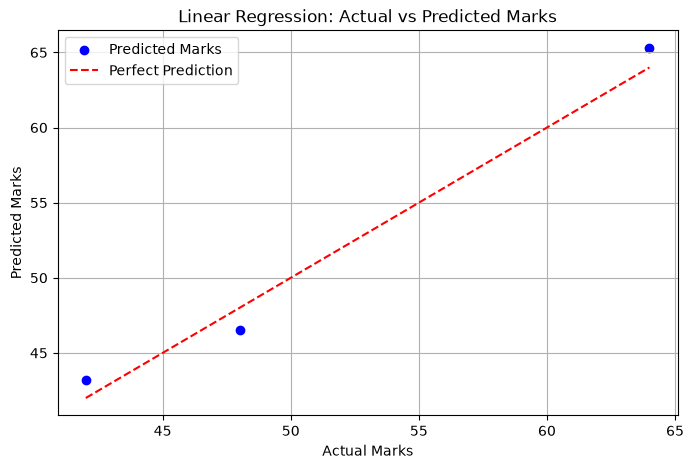

In [32]:
# Actual vs Predicted Marks
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    label="Predicted Marks"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Linear Regression: Actual vs Predicted Marks")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
print("=" * 45)
print("DAY 17: LINEAR REGRESSION MODEL SUMMARY")
print("=" * 45)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")

print("\nModel coefficients:")
print(f"Intercept: {coefficients[0]:.4f}")
print(f"Study Hours: {coefficients[1]:.4f}")
print(f"Attendance: {coefficients[2]:.4f}")
print(f"Previous Marks: {coefficients[3]:.4f}")

DAY 17: LINEAR REGRESSION MODEL SUMMARY
Training samples: 12
Testing samples: 3
Mean Absolute Error (MAE): 1.32
R² Score: 0.9796

Model coefficients:
Intercept: 11.5949
Study Hours: 2.4825
Attendance: -0.0039
Previous Marks: 0.6708


In [35]:
print("DAY 17 STATUS: COMPLETED")
print("Model: Linear Regression")
print("Training: NumPy least-squares method")
print("Evaluation: MAE and R² Score")
print("Visualization: Actual vs Predicted Marks")
print("Note: Scikit-learn fit had a Narwhals package error.")

DAY 17 STATUS: COMPLETED
Model: Linear Regression
Training: NumPy least-squares method
Evaluation: MAE and R² Score
Visualization: Actual vs Predicted Marks
Note: Scikit-learn fit had a Narwhals package error.
